# Used Car Price Tier Classification - Neural Network
**Dataset:** CarDekho Used Car Dataset (Extended, v3)  
**Framework:** PyTorch  
**Source:** https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?select=Car+details+v3.csv

***
# 0. Dataset Description

## Source
The dataset is the **CarDekho Used Car Dataset (v3)** from Kaggle:  
https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

The "Car details v3.csv" file is downloaded from my public github repository.

## Problem Context
CarDekho is a Indian used-car marketplace. This dataset contains listings of second-hand cars with various tehnical and commercial attributes. The classification target is the price tier of a car (budget, mid-range, premium) derived by binning the `selling_price` column into 3 categories.

This is the **same dataset used for the Classifiction Task (Assignment 1)**. A comparison between A1 best model (Random Forest) and the A2 neural network is included in the final section.

## Feature Description
| # | Feature | Meaning | Type | Examples |
|---|---|---|---|---|
| 1 | `year` | Year the car was manufactured | Numerical (discrete) | 2005, 2010, 2020 |
| 2 | `km_driven` | Total km of the car | Numerical (continuous) | 50000, 200000 |
| 3 | `fuel` | Type of fuel used | Nominal Categorical | Petrol, Diesel, CNG, LPG, Electric |
| 4 | `seller_type` | Who is selling the car | Nominal Categorical | Individual, Dealer, Trustmark Dealer |
| 5 | `transmission` | Gearbox type | Binary Categorical | Manual, Automatic |
| 6 | `owner` | Number of previous owners | Ordinal Categorical | First owner, Second Owner, ... |
| 7 | `mileage` | Fuel efficency(km/l or km/kg) | Numerical (continuous) | 23.4, 21.14 |
| 8 | `engine` | How big the engine is in CC | Numerical (contnuous) | 1248, 1498, 796 |
| 9 | `max_power` | Maximum engine power in bhp | Numerical (continuous) | 74, 103.52, 90 |
| 10 | `seats` | Number of seats | Numerical (discrete) | 4,5,7 |
| - | `price_tier`(target) | Price category | Nominal Categorical | budget, mid, premium | 

[`name` is dropped (too many unique strings). `torque` is dropped (inconsistent units). `selling_price` is dropped (target variable is derived from it).]

## Dataset Size and Class Distribution
- **Instances:** 8.128
- **Input Features:** 10
- **Target classes:** 3 (budget / mid / premium) 
- Class distribution is balanced by construction (~33% per class) by quantile binning 

***
## Imports and Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings,os,re,copy
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('All imports successful.')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}')

All imports successful.
PyTorch version: 2.12.0+cpu
Device: cpu


***
# 1. Data Loading and Preprocessing

## 1.1 Download and Load Dataset

In [4]:
url = "https://raw.githubusercontent.com/Raulqy8/Classification-Task-UsedCarPriceTierClassification/main/Car%20details%20v3.csv"

df_raw = pd.read_csv(url)
print(f'Raw shape: {df_raw.shape}')
df_raw.head()

Raw shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 1.2 Overview

In [5]:
print('Columns: ', df_raw.columns.tolist())
print('\nData types:')
print(df_raw.dtypes)
print('\nMissing values per column:')
print(df_raw.isnull().sum())
print('Basic sattistics:')
df_raw.describe(include='all')

Columns:  ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']

Data types:
name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

Missing values per column:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64
Basic sattistics:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
count,8128,8128.000000,8.128000e+03,8.128000e+03,8128,8128,8128,8128,7907,7907,7913,7906,7907.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,393,121,322,441,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,NaN
freq,129,NaN,NaN,NaN,4402,6766,7078,5289,225,1017,377,530,NaN
mean,NaN,2013.804011,6.382718e+05,6.981951e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.416719
std,NaN,4.044249,8.062534e+05,5.655055e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959588
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,2011.000000,2.549990e+05,3.500000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,2015.000000,4.500000e+05,6.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,2017.000000,6.750000e+05,9.800000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


## 1.3 Data Cleaning

The `mileage`, `engine` and `max_power` are stored as strings("19.7 kmpl"). We strip the units and convert them to float. Rows with unparseable values become NaN and will be handled by imputation in the preprocessing stage.

In [6]:
df = df_raw.copy()
df.drop(columns=['name', 'torque'], inplace=True, errors='ignore')

def extract_numeric(series):
    return pd.to_numeric(series.str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

df['mileage'] = extract_numeric(df['mileage'])
df['engine'] = extract_numeric(df['engine'])
df['max_power'] = extract_numeric(df['max_power'])

print('Dtypes after conversion: ')
print(df.dtypes)
print('\nMissing values after conversion:')
print(df.isnull().sum())

Dtypes after conversion: 
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
seats            float64
dtype: object

Missing values after conversion:
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        216
seats            221
dtype: int64


## 1.4 Create Target Variable

We derive the classification target `price_tier` by splitting `selling_price` into 3 quantile-based bins:
- budget: bottom 33%
- mid: middle 33%
- premium: top 33%

Quantile-based binning is chosen because it produces balanced classes regardless of the price distribution. After creating the target, `selling_price` is dropped from the features.

Dataset shape after traget creation: (8128, 11)

Class distribution:
price_tier
mid        2834
budget     2722
premium    2572
Name: count, dtype: int64


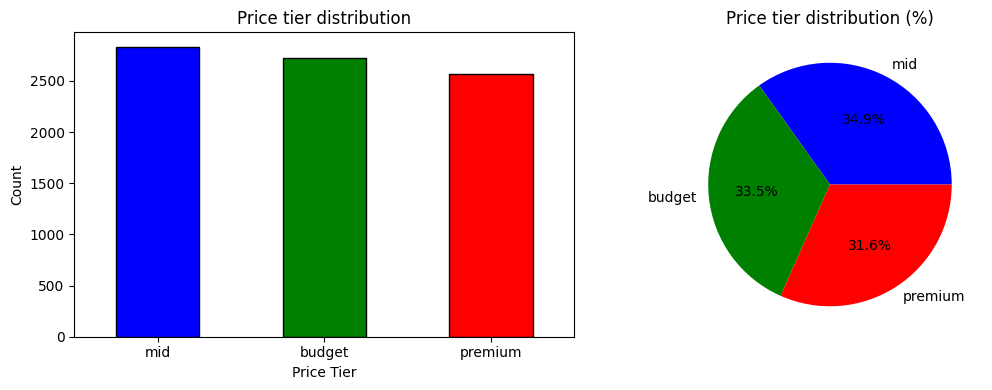

In [7]:
df['price_tier'] = pd.qcut(df['selling_price'], q=3, labels=['budget', 'mid', 'premium'])
df.drop(columns=['selling_price'], inplace=True)
df.dropna(subset=['price_tier'], inplace=True)

print(f'Dataset shape after traget creation: {df.shape}' )
print('\nClass distribution:')
print(df['price_tier'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['price_tier'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=['blue', 'green', 'red'], edgecolor='black')
axes[0].set_title('Price tier distribution')
axes[0].set_xlabel('Price Tier')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['blue', 'green', 'red'])
axes[1].set_title('Price tier distribution (%)')
plt.tight_layout()
plt.savefig('price_tier_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 1.5 Encoding and Preprocessing Strategy
Neural networks require all inputs to be numeric and scaled.

| **Group** | **Features** | **Strategy** | **Reason** |
|---|---|---|---|
| **Numerical** | `year`, `km_driven`, `mileage`, `engine`, `max_power`, `seats` | Median imputation + StandardScaler | NaN values present; neural networks are sensitive to feature scale
| **Ordinal categorical** | `owner` | OrdinalEncoder with explicit order | "First Owner" < "Second Owner" | 
| **Nominal Categorical** | `fuel`, `seller_type`, `transmission` | OneHotEncoder | No natural order; integer encoding would imply false ordering |

Unlike decision trees, neural networks compute weighted sums of inputs. If `km_driven`(~100,000) is not scaled, its gradients will dominate those of other features (ex: `seats`(values 2-8)), causing  unstable or slow training. `StandardScaler`(zero mean, unit variance) ensures all features contribute equally at the start of training.

In [8]:
TARGET = 'price_tier'
feature_cols = [col for col in df.columns if col != TARGET]
X_raw = df[feature_cols].copy()

le = LabelEncoder()
y = le.fit_transform(df[TARGET])
print(f'Target classes: {le.classes_} -> encoded as {list(range(len(le.classes_)))}')

numerical_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
ordinal_features = ['owner']
nominal_features = ['fuel', 'seller_type', 'transmission']
owner_order = ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']

print(f'\nNumerical ({len(numerical_features)}): {numerical_features}')
print(f'Ordinal ({len(ordinal_features)}): {ordinal_features}')
print(f'Nominal ({len(nominal_features)}): {nominal_features}')

# All features must be scaled
numerical_transoformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[owner_order], handle_unknown='use_encoded_value', unknown_value=-1)),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transoformer, numerical_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features)
])
print('Preprocessing pipeline defined')

Target classes: ['budget' 'mid' 'premium'] -> encoded as [0, 1, 2]

Numerical (6): ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Ordinal (1): ['owner']
Nominal (3): ['fuel', 'seller_type', 'transmission']
Preprocessing pipeline defined


In [9]:
# Transformed output
X_preview = preprocessor.fit_transform(X_raw)
ohe_cols = preprocessor.named_transformers_['nom']['encoder'].get_feature_names_out(nominal_features)
all_feature_names = numerical_features + ordinal_features + list(ohe_cols)

print(f'Transformed matrix: {X_preview.shape}')
print(f'Total features: {len(all_feature_names)}')
print(f'Feature names: {all_feature_names}')

Transformed matrix: (8128, 16)
Total features: 16
Feature names: ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner', 'fuel_CNG', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Automatic', 'transmission_Manual']


***
# 2. Train / Validation / Test Split
For neural networks we need **3** splits instead of 2;
- **Train (64%):** used to update model weights
- **Validation (16%):** used during training to monitor overfitting and tune hyperparameters (never seen by the model during weight updates)
- **Test (20%):** held out until final evaluation only

We use `stratify=y` at both split steps to preserve class proportions (same reasons as in the classification task A1).

In [10]:
# First spltit: 80% train+val, 20% test
X_trainval, X_test_raw, y_trainval, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Second split: 80% train, 20% val (64% train, 16% val overall)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=RANDOM_STATE, stratify=y_trainval
)

print(f'Train: {X_train_raw.shape[0]} samples ({X_train_raw.shape[0]/len(X_raw)*100:.1f}%)')
print(f'Validation: {X_val_raw.shape[0]} samples ({X_val_raw.shape[0]/len(X_raw)*100:.1f}%)')
print(f'Test: {X_test_raw.shape[0]} samples ({X_test_raw.shape[0]/len(X_raw)*100:.1f}%)')

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

for name_s, y_s in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = pd.Series(y_s).value_counts(normalize=True).sort_index()
    print(f'{name_s}: {dict(zip(le.classes_, (dist*100).round(1)))}%')

Train: 5201 samples (64.0%)
Validation: 1301 samples (16.0%)
Test: 1626 samples (20.0%)
Train: {'budget': 33.5, 'mid': 34.9, 'premium': 31.6}%
Val: {'budget': 33.4, 'mid': 34.9, 'premium': 31.7}%
Test: {'budget': 33.5, 'mid': 34.9, 'premium': 31.6}%


***
# 3. Performance Metric Selection

**Chosen primary metric: Weighted F1-score**  
F1 is the harmonic mean of precision and recall. The **weighted** variant averages per-class F1 scores weighted by their support, making it robust to any residual class imbalance. We additionally report the full **classification report** (per-class precision, recall, F1) and **confusion matrix** for each model.

Using the same metric as in previous task helps with a fair comparison between A1 and A2 in the final section.

***
# 4. Feature Selection

1. **Slim model comparison:** train the MLP on a reduced feature set and compare it to the full model.
2. **Feature engineering:** propose new features, evaluate their MI, and retain the best MLP on the extended set.

## 4.1 Mutual Information Ranking

We compute the MI on the training set. This ranks how much information each feature shares with the target, independently of the model.

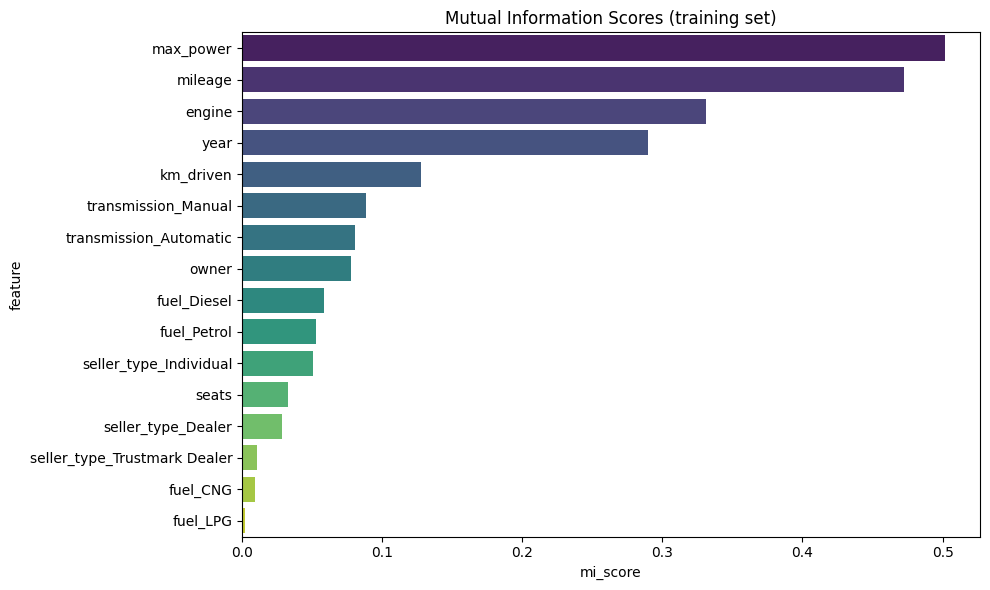

                     feature  mi_score
                   max_power  0.501626
                     mileage  0.472795
                      engine  0.331367
                        year  0.289642
                   km_driven  0.127445
         transmission_Manual  0.088434
      transmission_Automatic  0.080443
                       owner  0.077742
                 fuel_Diesel  0.058801
                 fuel_Petrol  0.052813
      seller_type_Individual  0.050724
                       seats  0.032776
          seller_type_Dealer  0.028389
seller_type_Trustmark Dealer  0.010779
                    fuel_CNG  0.009316
                    fuel_LPG  0.002126


In [11]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
ohe_cols = preprocessor.named_transformers_['nom']['encoder'].get_feature_names_out(nominal_features)
all_feature_names = numerical_features + ordinal_features + list(ohe_cols)

mi_df = pd.DataFrame({'feature': all_feature_names, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df, x='mi_score', y='feature', palette='viridis')
plt.title('Mutual Information Scores (training set)')
plt.tight_layout()
plt.show()
print(mi_df.to_string(index=False))

***
# 5. Neural Network Model

## 5.1 Architecture Definition

We define a **Multi Layer Perceptron (MLP)** with the following design choices:

|Component|Choice|Justification|
|---|---|---|
|Hidden Layers| 4 | Deep enaugh to learn non-linear interactions between features|
|Activation| ReLU | Standard for MLPs; avoids vanishing gradients better than sigmoid|
|Batch Normalisation| After each linear layer | Stabilises training, allows higher learning rates, acts as a regulizer|
|Dropout| After each activation | Prevents overfitting by randomly zeroing neurons during training|
|Output layer| Linear -> CrossEntropyLoss | PyTorch's `CrossEntropyLoss` applies softmax internally => no need to add it|
|Optimiser| Adam | Adaptive learning rate; converges faster than plain SGD on tabular data|

In [12]:
# Configurable MLP for multiclass classification
# Architecture: Input -> [Linear -> BN -> ReLU -> Dropout]*4 -> Output

class CarMLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim = 128, dropout_rate=0.3):
        super(CarMLP, self).__init__()
        
        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            )
        
        self.network = nn.Sequential(
            block(input_dim, hidden_dim),
            block(hidden_dim, hidden_dim*2),
            block(hidden_dim*2, hidden_dim),
            block(hidden_dim, hidden_dim//2),
            nn.Linear(hidden_dim//2, num_classes)
        )

    def forward(self, x):
        return self.network(x)
INPUT_DIM_BASE = X_train.shape[1]
NUM_CLASSES = len(le.classes_)
mock = CarMLP(input_dim=INPUT_DIM_BASE, num_classes=NUM_CLASSES, hidden_dim=128, dropout_rate=0.3)
mock_in = torch.randn(8, INPUT_DIM_BASE)
mock_out = mock(mock_in)
print(f'Mock output shape: {mock_out.shape}')
print(mock) 

Mock output shape: torch.Size([8, 3])
CarMLP(
  (network): Sequential(
    (0): Sequential(
      (0): Linear(in_features=16, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
    (3): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_runni

## 5.2 Training and Evaluation Helpers

In [13]:
def make_tensors(X_np, y_np):
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_np, dtype=torch.long).to(DEVICE)
    return X_t, y_t

def make_loader(X_np, y_np, batch_size=64, shuffle=True):
    X_t, y_t = make_tensors(X_np, y_np)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += len(y_batch)
    
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += len(y_batch)
    
    return total_loss / total, correct / total

@torch.no_grad()
def predict(model, X_np):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    return model(X_t).argmax(dim=1).cpu().numpy()


# Main training loop with early stopping

def train_model(model, X_tr, y_tr, X_val, y_val, lr=1e-3, epochs=80, batch_size=64, patience=12, verbose=True):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    train_loader = make_loader(X_tr, y_tr, batch_size=batch_size)
    val_loader = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    patience_count = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                if verbose:
                    print(f'Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})')
                break

        if verbose and epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | '
                  f'Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
            
    model.load_state_dict(best_state)
    return history, model

def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch') ; axes[0].set_ylabel('Cross_entropy Loss')
    axes[0].set_title(f'{title} Accuracy')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], label='Val Acc')
    axes[1].set_xlabel('Epoch') ; axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def full_evaluation(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_tr = predict(model, X_tr)
    y_pred_te = predict(model, X_te)

    f1_tr = f1_score(y_tr, y_pred_tr, average='weighted')
    f1_te = f1_score(y_te, y_pred_te, average='weighted')
    acc_tr = accuracy_score(y_tr, y_pred_tr)
    acc_te = accuracy_score(y_te, y_pred_te)

    print(f'Model {name}')
    print(f'Train Accuracy: {acc_tr:.4f}, F1-score: {f1_tr:.4f}')
    print(f'Test Accuracy: {acc_te:.4f}, F1-score: {f1_te:.4f}')

    gap = f1_tr - f1_te
    if gap > 0.07:
        print(f'Overfitting (gap={gap:.4f})')
    elif f1_te < 0.70:
        print(f'Underfitting (test F1={f1_te:.4f})')
    else:
        print(f'Good fit (gap={gap:.4f})')

    print(f'\nClassification report (test):')
    print(classification_report(y_te, y_pred_te, target_names=le.classes_))

    cm = confusion_matrix(y_te, y_pred_te)
    fig,axes = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=axes, cmap='Blues', colorbar=False)
    axes.set_title(f'Confusion Matrix - {name}')
    plt.show()

    return {'model': name, 'train_f1': f1_tr, 'test_f1': f1_te, 'train_acc': acc_tr, 'test_acc': acc_te, 'gap': gap}

print('All helpers defined')



All helpers defined


## 5.3 Slim Model Comparison
We train 2 MLP versions with default hyperparameters:
- **Full model:** all encoded features
- **Slim model:** only top 6 features by mi_score

This helps us to see if low-ranked features contribute meaningful or are just noise. We use the **validation F1** for comparison.

In [14]:
TOP_K = 6
top_feature_names = mi_df.head(TOP_K)['feature'].tolist()
top_indices = [list(mi_df['feature']).index(f) for f in top_feature_names]

X_train_slim = X_train[:, top_indices]
X_val_slim = X_val[:, top_indices]
X_test_slim = X_test[:, top_indices]

print(f'Full model input dim: {X_train.shape[1]}')
print(f'Slim model input dim: {len(top_indices)}')
print(f'Top {TOP_K} features: {top_feature_names}')

# Full model

torch.manual_seed(RANDOM_STATE)
full_mlp = CarMLP(input_dim=X_train.shape[1], num_classes=NUM_CLASSES, hidden_dim=128, dropout_rate=0.3)
_, full_mlp = train_model(full_mlp, X_train, y_train, X_val, y_val, lr=1e-3, epochs=80, batch_size=64, patience=10, verbose=False)
val_f1_full = f1_score(y_val, predict(full_mlp, X_val), average='weighted')

# Slim model
torch.manual_seed(RANDOM_STATE)
slim_mlp = CarMLP(input_dim=len(top_indices), num_classes=NUM_CLASSES, hidden_dim=128, dropout_rate=0.3)
_, slim_mlp = train_model(slim_mlp, X_train_slim, y_train, X_val_slim, y_val, lr=1e-3, epochs=80, batch_size=64, patience=10, verbose=False)
val_f1_slim = f1_score(y_val, predict(slim_mlp, X_val_slim), average='weighted')

print(f'\nFull model ({X_train.shape[1]} features) validation F1: {val_f1_full:.4f}')
print(f'Slim model ({len(top_indices)} features) validation F1: {val_f1_slim:.4f}')
diff = val_f1_full - val_f1_slim
print(f'Difference: {diff:.4f} ({"full better" if diff > 0 else "slim better" if diff < 0 else "equal"})')

Full model input dim: 16
Slim model input dim: 6
Top 6 features: ['max_power', 'mileage', 'engine', 'year', 'km_driven', 'transmission_Manual']

Full model (16 features) validation F1: 0.8205
Slim model (6 features) validation F1: 0.8147
Difference: 0.0058 (full better)


**Feature selection conclusion:**  
After training both models, the full model has a better F1 validation. Although the difference is minor in this case (0.0058) which shows that the slim model might be preffered for simplicity, this dataset only has 10 original features therefor, **we keep all the features in the final model** (is not worth to risk discarding usefull information given the marginality of the gap). 

## 5.4 Baseline Model - Training and Evaluation

We first train a baseline MLP with default hyperparameters to establish a refrence point and inspect the loss/accuracy curves for signs of overfitting or underfitting.

Training baseline MLP...
Epoch  10 | Train Loss: 0.4671, Train Acc: 0.7898 | Val Loss: 0.4291, Val Acc: 0.8078
Epoch  20 | Train Loss: 0.4657, Train Acc: 0.7923 | Val Loss: 0.4392, Val Acc: 0.7971
Epoch  30 | Train Loss: 0.4336, Train Acc: 0.8050 | Val Loss: 0.4127, Val Acc: 0.8201
Epoch  40 | Train Loss: 0.4384, Train Acc: 0.8016 | Val Loss: 0.4175, Val Acc: 0.8109
Early stopping at epoch 48 (best val loss: 0.4064)


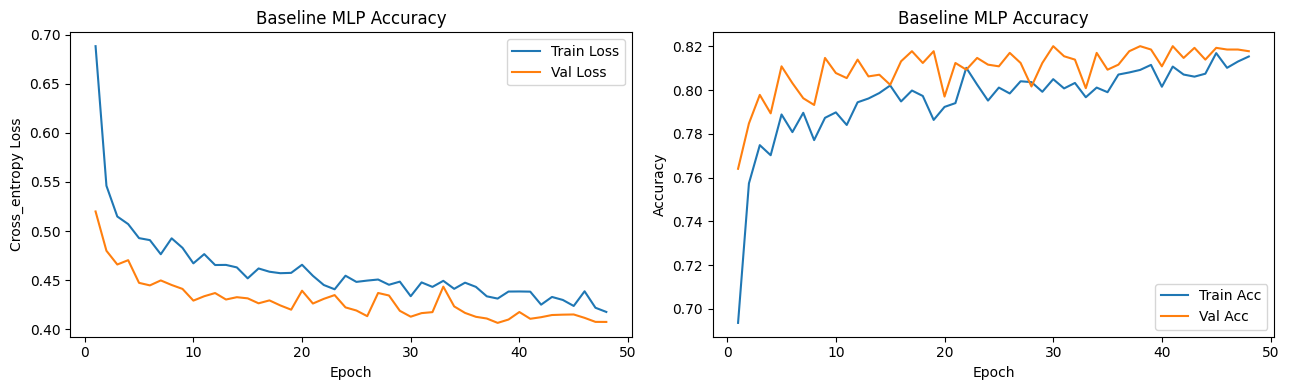

Model MLP baseline
Train Accuracy: 0.8414, F1-score: 0.8413
Test Accuracy: 0.8210, F1-score: 0.8211
Good fit (gap=0.0201)

Classification report (test):
              precision    recall  f1-score   support

      budget       0.88      0.89      0.89       545
         mid       0.74      0.75      0.75       567
     premium       0.84      0.83      0.83       514

    accuracy                           0.82      1626
   macro avg       0.82      0.82      0.82      1626
weighted avg       0.82      0.82      0.82      1626



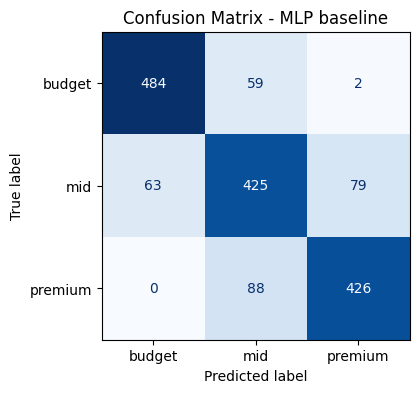

In [15]:
torch.manual_seed(RANDOM_STATE)

baseline_model = CarMLP(input_dim = INPUT_DIM_BASE, num_classes=NUM_CLASSES, hidden_dim=128, dropout_rate=0.3)

print('Training baseline MLP...')
baseline_history, baseline_model = train_model(
    baseline_model, X_train, y_train, X_val, y_val, lr = 1e-3, epochs=80, batch_size=64, patience=10, verbose=True)

plot_history(baseline_history, title='Baseline MLP')

result = []
r = full_evaluation('MLP baseline', baseline_model, X_train, y_train, X_test, y_test)
result.append(r)

**Conclusion on the Baseline MLP:**
The baseline model achieved a weighted F1-score of 0.8413 on the training set and 0.8211 on the test set.
The small performance gap (2%) suggests that the model generalizes well and does not suffer from severe overfitting. Validation performance started to stagnate after several epochs, therefore early stopping prevented unnecessary training and reduced overfitting risk.

## 5.5 Hyperparameter tunning
We perform a **manual grid search** over the most impactful hyperparameters:
|**Parameter**|**values searched**|**Effect**|
|---|---|---|
|`hidden_dim`|64,128,256|Controls model capacity|
|`dropout_rate`|0.2, 0.3, 0.4|Controls regulariastion strenght|
|`lr`|1e-3, 5e-4| COntrols step size during gradient descent|
|`batch_size`|32, 64| Affects gradient noise and speed|

We use **validation F1** (not valid loss) as the selection criterion, since it is our primary evaluation metric and is directly comparable to A1 results.  
We use manual grid search loop instead of GridSearchCV because PyTorch models are not compatible with scikit-learn's CV wrapper.

In [16]:
param_grid = {
    'hidden_dim': [64, 128, 256],
    'dropout_rate': [0.2, 0.3, 0.4],
    'lr': [1e-3, 5e-4],
    'batch_size': [32, 64]
}

grid_results = []
configs = list(ParameterGrid(param_grid))
print(f'Total configurations to try: {len(configs)}')

for i, params in enumerate(configs):
    torch.manual_seed(RANDOM_STATE)
    model = CarMLP(input_dim=INPUT_DIM_BASE, num_classes=NUM_CLASSES, hidden_dim=params['hidden_dim'], dropout_rate=params['dropout_rate'])

    _, trained = train_model(
        model, X_train, y_train, X_val, y_val,
        lr = params['lr'],
        epochs=80, batch_size=params['batch_size'], patience=10, verbose=False
    )

    val_preds = predict(trained, X_val)
    val_f1 = f1_score(y_val, val_preds, average='weighted')
    grid_results.append({**params, 'val_f1': val_f1})

    if (i+1)%6==0 or (i+1)==len(configs):
        print(f'[{i+1}/{len(configs)}] Last val F1: {val_f1:.4f} | params: {params}')
    
grid_df = pd.DataFrame(grid_results).sort_values('val_f1', ascending=False)
print('\nTop 5 configurations:')
print(grid_df.head(5).to_string(index=False))

Total configurations to try: 36
[6/36] Last val F1: 0.8214 | params: {'batch_size': 32, 'dropout_rate': 0.2, 'hidden_dim': 256, 'lr': 0.0005}
[12/36] Last val F1: 0.8190 | params: {'batch_size': 32, 'dropout_rate': 0.3, 'hidden_dim': 256, 'lr': 0.0005}
[18/36] Last val F1: 0.8137 | params: {'batch_size': 32, 'dropout_rate': 0.4, 'hidden_dim': 256, 'lr': 0.0005}
[24/36] Last val F1: 0.8254 | params: {'batch_size': 64, 'dropout_rate': 0.2, 'hidden_dim': 256, 'lr': 0.0005}
[30/36] Last val F1: 0.8260 | params: {'batch_size': 64, 'dropout_rate': 0.3, 'hidden_dim': 256, 'lr': 0.0005}
[36/36] Last val F1: 0.8210 | params: {'batch_size': 64, 'dropout_rate': 0.4, 'hidden_dim': 256, 'lr': 0.0005}

Top 5 configurations:
 batch_size  dropout_rate  hidden_dim     lr   val_f1
         64           0.2         256 0.0010 0.835043
         64           0.2          64 0.0010 0.831514
         64           0.3         256 0.0010 0.828897
         64           0.3         256 0.0005 0.826002
         6

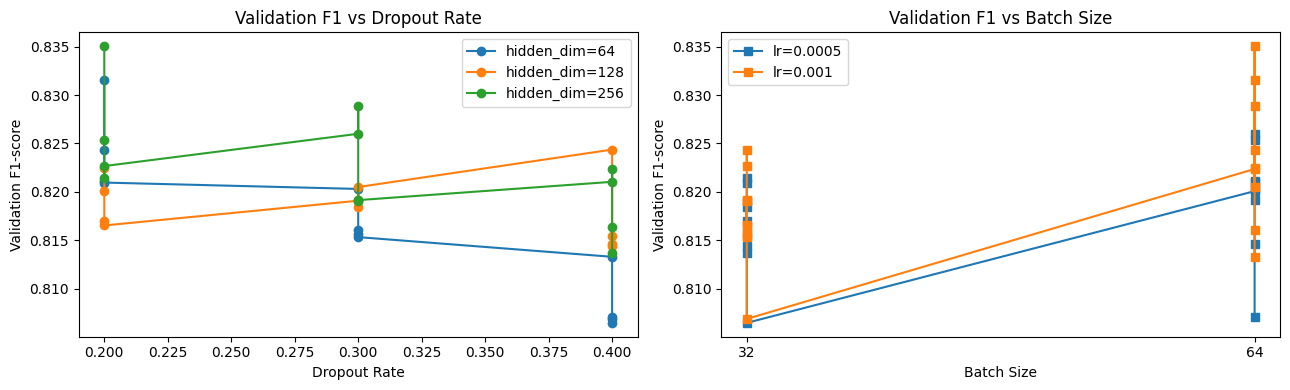

In [44]:
# Grid Search Results

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hd, grp in grid_df.groupby('hidden_dim'):
    grp_sorted = grp.sort_values('dropout_rate')
    axes[0].plot(grp_sorted['dropout_rate'], grp_sorted['val_f1'], marker='o', label=f'hidden_dim={hd}')

axes[0].set_xlabel('Dropout Rate')
axes[0].set_ylabel('Validation F1-score')
axes[0].set_title('Validation F1 vs Dropout Rate')
axes[0].legend()

for lr_val, grp in grid_df.groupby('lr'):
    grp_sorted = grp.sort_values('batch_size')
    axes[1].plot(grp_sorted['batch_size'].astype(str), grp_sorted['val_f1'], marker='s', label=f'lr={lr_val}')

axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Validation F1-score')
axes[1].set_title('Validation F1 vs Batch Size')
axes[1].legend()

plt.tight_layout()
plt.show()

Best hyperparameters: {'batch_size': 64.0, 'dropout_rate': 0.2, 'hidden_dim': 256.0, 'lr': 0.001, 'val_f1': 0.8350428364557394}

Retraining best model...
Epoch  10 | Train Loss: 0.4354, Train Acc: 0.8025 | Val Loss: 0.4200, Val Acc: 0.8086
Epoch  20 | Train Loss: 0.4152, Train Acc: 0.8154 | Val Loss: 0.4162, Val Acc: 0.8232
Epoch  30 | Train Loss: 0.3883, Train Acc: 0.8229 | Val Loss: 0.4239, Val Acc: 0.8194
Epoch  40 | Train Loss: 0.3525, Train Acc: 0.8437 | Val Loss: 0.4030, Val Acc: 0.8340
Epoch  50 | Train Loss: 0.3421, Train Acc: 0.8456 | Val Loss: 0.4045, Val Acc: 0.8232
Early stopping at epoch 55 (best val loss: 0.4030)


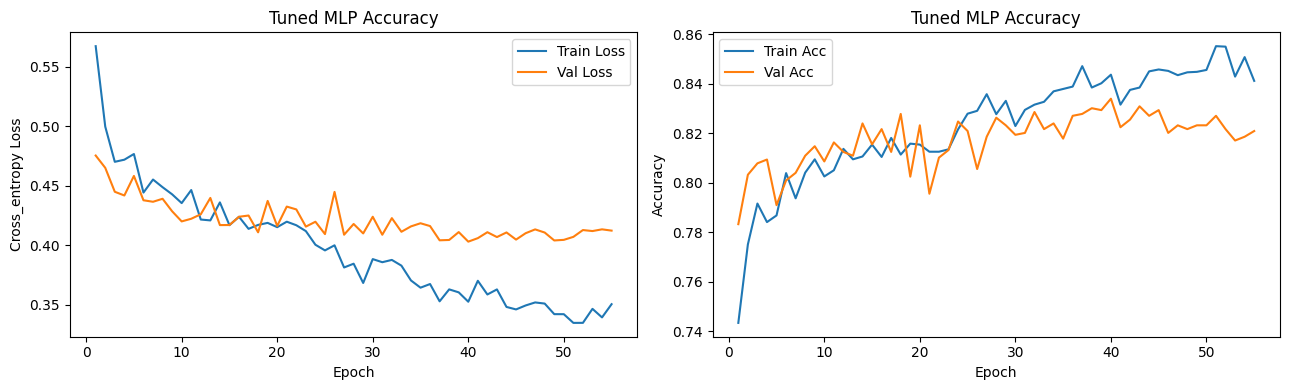

In [18]:
# Train best configurations

best_params = grid_df.iloc[0].to_dict()
print(f'Best hyperparameters: {best_params}')

torch.manual_seed(RANDOM_STATE)
best_model = CarMLP(
    input_dim=INPUT_DIM_BASE,
    num_classes=NUM_CLASSES,
    hidden_dim=int(best_params['hidden_dim']),
    dropout_rate=float(best_params['dropout_rate'])
)

print('\nRetraining best model...')
best_history, best_model = train_model(
    best_model, X_train, y_train, X_val, y_val,
    lr = float(best_params['lr']),
    epochs=120,
    batch_size=int(best_params['batch_size']),
    patience=15,
    verbose=True
)

plot_history(best_history, 'Tuned MLP')

Model Tuned MLP
Train Accuracy: 0.8712, F1-score: 0.8720
Test Accuracy: 0.8376, F1-score: 0.8388
Good fit (gap=0.0333)

Classification report (test):
              precision    recall  f1-score   support

      budget       0.90      0.88      0.89       545
         mid       0.75      0.81      0.78       567
     premium       0.88      0.82      0.85       514

    accuracy                           0.84      1626
   macro avg       0.84      0.84      0.84      1626
weighted avg       0.84      0.84      0.84      1626



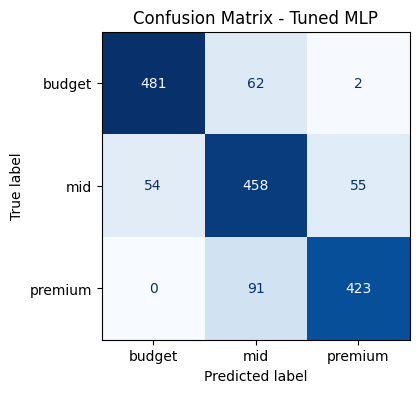

In [19]:
r = full_evaluation('Tuned MLP', best_model, X_train, y_train, X_test, y_test)
result = [x for x in result if x['model'] != r['model']]
result.append(r)

***
# 6. Feature Engineering

We evaluate whether the 3 engineered features from A1 (`car_age`, `km_per_year`, `power_to_engine`) also improve the neural network. We retain the best MLP configuration on the extended feature set and compare.

The neural network may benefit less from these features than the decision tree, since deep networks can learn complex interactions implicitly.

In [20]:
# Add new features

def add_engineered_features(X_df):
    X_new = X_df.copy()
    X_new['car_age'] = 2026 - X_new['year']
    X_new['km_per_year'] = X_new['km_driven'] / (X_new['car_age']+1)
    X_new['power_to_engine'] = X_new['max_power'] / X_new['engine'].replace(0, np.nan)
    return X_new

X_train_eng = add_engineered_features(X_train_raw)
X_val_eng = add_engineered_features(X_val_raw)
X_test_eng = add_engineered_features(X_test_raw)

new_num = numerical_features + ['car_age', 'km_per_year', 'power_to_engine']
preprocessor_eng = ColumnTransformer(transformers=[
    ('num', numerical_transoformer, new_num),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features)
])

X_train_e = preprocessor_eng.fit_transform(X_train_eng)
X_val_e = preprocessor_eng.transform(X_val_eng)
X_test_e = preprocessor_eng.transform(X_test_eng)

INPUT_DIM_ENG = X_train_e.shape[1]

print(f'Engineered feature dim: {INPUT_DIM_ENG} (added 3 features)')

Engineered feature dim: 19 (added 3 features)


Training MLP with engineered features...
Epoch  10 | Train Loss: 0.4386, Train Acc: 0.8006 | Val Loss: 0.4194, Val Acc: 0.8132
Epoch  20 | Train Loss: 0.3997, Train Acc: 0.8241 | Val Loss: 0.4194, Val Acc: 0.8125
Epoch  30 | Train Loss: 0.3714, Train Acc: 0.8371 | Val Loss: 0.4224, Val Acc: 0.8155
Epoch  40 | Train Loss: 0.3484, Train Acc: 0.8504 | Val Loss: 0.4207, Val Acc: 0.8178
Epoch  50 | Train Loss: 0.3398, Train Acc: 0.8471 | Val Loss: 0.4099, Val Acc: 0.8186
Epoch  60 | Train Loss: 0.3244, Train Acc: 0.8618 | Val Loss: 0.4104, Val Acc: 0.8194
Early stopping at epoch 66 (best val loss: 0.4058)


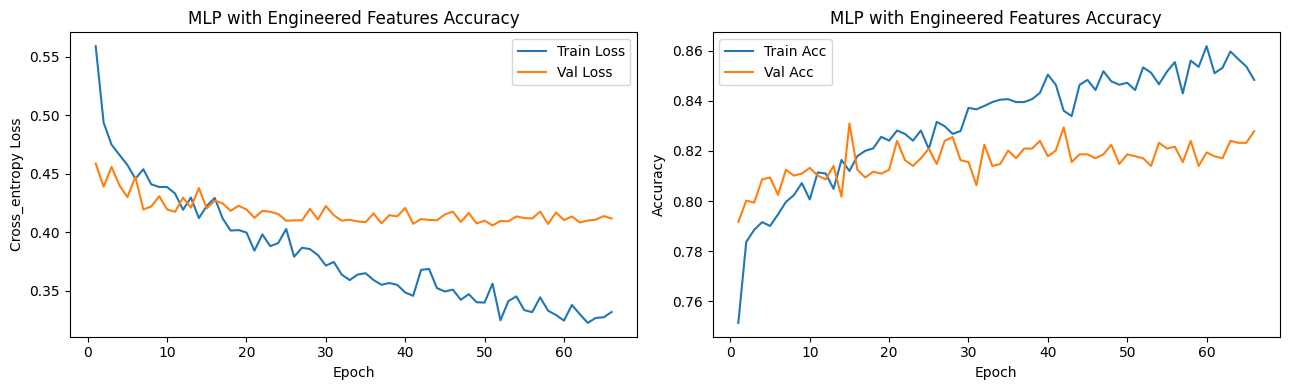

In [21]:
# Training model with new features

torch.manual_seed(RANDOM_STATE)
eng_model = CarMLP(input_dim=INPUT_DIM_ENG, num_classes=NUM_CLASSES, hidden_dim=int(best_params['hidden_dim']), dropout_rate=float(best_params['dropout_rate']))

print('Training MLP with engineered features...')
eng_history, eng_model = train_model(
    eng_model, X_train_e, y_train, X_val_e, y_val,
    lr = float(best_params['lr']),
    epochs=120,
    batch_size=int(best_params['batch_size']),
    patience=15,
    verbose=True
)

plot_history(eng_history, 'MLP with Engineered Features')

Model MLP + Engineered Features
Train Accuracy: 0.8793, F1-score: 0.8800
Test Accuracy: 0.8296, F1-score: 0.8303
Good fit (gap=0.0498)

Classification report (test):
              precision    recall  f1-score   support

      budget       0.88      0.89      0.88       545
         mid       0.75      0.78      0.76       567
     premium       0.87      0.82      0.85       514

    accuracy                           0.83      1626
   macro avg       0.83      0.83      0.83      1626
weighted avg       0.83      0.83      0.83      1626



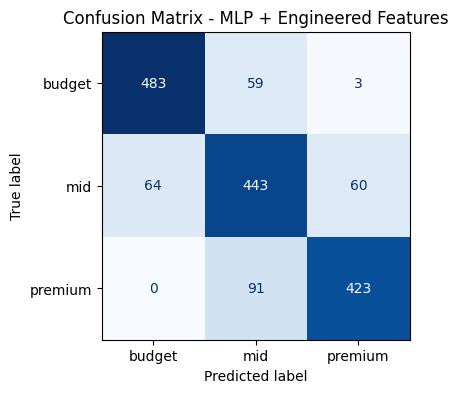


MLP Tuned (base features) test F1: 0.8388
MLP + Engineered Features test F1: 0.8303
Impact: no gain


In [22]:
# Evaluate model with engineered features
r = full_evaluation('MLP + Engineered Features', eng_model, X_train_e, y_train, X_test_e, y_test)
result = [x for x in result if x['model'] != r['model']]
result.append(r)

tuned_f1 = next(x['test_f1'] for x in result if x['model'] == 'Tuned MLP')
eng_f1 = r['test_f1']

print(f'\nMLP Tuned (base features) test F1: {tuned_f1:.4f}')
print(f'MLP + Engineered Features test F1: {eng_f1:.4f}')
print(f"Impact: {'imporved' if eng_f1 > tuned_f1 else 'no gain'}")

***
# 7. Neural network - Results Summary

                    model  train_acc  test_acc  train_f1  test_f1
                Tuned MLP   0.871179  0.837638  0.872012 0.838755
MLP + Engineered Features   0.879254  0.829643  0.880029 0.830277
             MLP baseline   0.841377  0.821033  0.841271 0.821137


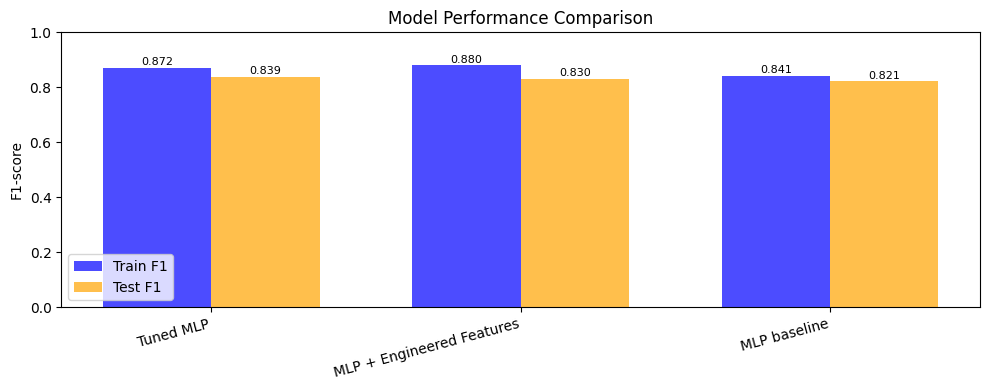

In [23]:
a2_df = pd.DataFrame(result).sort_values('test_f1', ascending=False)

print(a2_df[['model', 'train_acc', 'test_acc', 'train_f1', 'test_f1']].to_string(index=False))

fig,ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(a2_df))
w = 0.35
b1 = ax.bar(x-w/2, a2_df['train_f1'], w, label='Train F1', color='blue', alpha=0.7)
b2 = ax.bar(x+w/2, a2_df['test_f1'], w, label='Test F1', color='orange', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(a2_df['model'], rotation=15, ha='right')
ax.set_ylabel('F1-score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.set_ylim(0, 1)
for b in list(b1)+list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

***
# A1 vs A2 Comparison

We compare the best model from Assigment 1 (Tuned Random Forest) against the best neural network from this assignment.
Both models are evaluated on the same test set using the same metric (Weighted F1), making the comparison fair and meaningful.

## A1 Results (from A1)

|**Model**|**Train F1**|**Test F1**|**Train Acc**| **Test Acc**|
|---|---|---|---|---|
|Random Forest(Tuned)|0.965103|0.876207|0.965088|0.876384|
|SVM (Tuned) | 0.862020| 0.838031|0.861273 |0.837023|
|Decision Tree (Tuned) | 0.896211 | 0.840479 | 0.895878| 0.840098|

In [39]:
a1_results = [
    {'model': 'A1-Random Forest (Tuned)', 'test_f1':0.8762, 'train_f1': 0.9651, 'test_acc': 0.8764, 'train_acc': 0.9651},
    {'model': 'A1 - SVM (Tuned)', 'test_f1': 0.8380, 'train_f1': 0.8620,'test_acc': 0.8370, 'train_acc': 0.8613},
    {'model': 'A1 - Decision Tree (Tuned)', 'test_f1': 0.8405, 'train_f1': 0.8962,'test_acc': 0.8401, 'train_acc': 0.8959},
]

best_a2 = max(result, key=lambda x: x['test_f1'])
best_a2_labeled = {**best_a2, 'model':f'A2 - {best_a2["model"]}'}

comparison_data = a1_results + [best_a2_labeled]
comp_df = pd.DataFrame(comparison_data).sort_values('test_f1', ascending=False)

print(comp_df[['model', 'train_f1', 'test_f1', 'test_acc']].to_string(index=False))

                     model  train_f1  test_f1  test_acc
  A1-Random Forest (Tuned)  0.965100 0.876200  0.876400
A1 - Decision Tree (Tuned)  0.896200 0.840500  0.840100
            A2 - Tuned MLP  0.872012 0.838755  0.837638
          A1 - SVM (Tuned)  0.862000 0.838000  0.837000


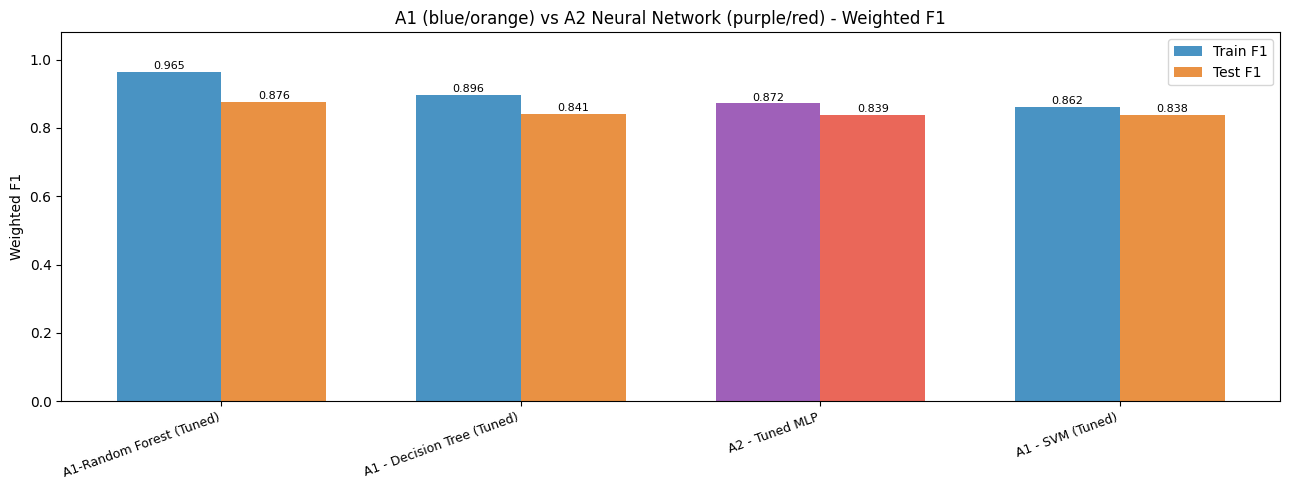

In [40]:
# Comparison plot

fig, ax = plt.subplots(figsize=(13, 5))
x  = np.arange(len(comp_df))
w  = 0.35
colors_train = ['#2980b9' if 'A1' in m else '#8e44ad' for m in comp_df['model']]
colors_test  = ['#e67e22' if 'A1' in m else '#e74c3c' for m in comp_df['model']]

b1 = ax.bar(x - w/2, comp_df['train_f1'], w, label='Train F1',
            color=colors_train, alpha=0.85)
b2 = ax.bar(x + w/2, comp_df['test_f1'],  w, label='Test F1',
            color=colors_test, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comp_df['model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Weighted F1')
ax.set_title('A1 (blue/orange) vs A2 Neural Network (purple/red) - Weighted F1')
ax.set_ylim(0, 1.08)

plt.legend()

for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008,
            f'{b.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## Analysis: A1 vs A2

| Aspect | A1 — Random Forest | A2 — Neural Network (MLP) |
|---|---|---|
| **Model type** | Ensemble of Decision Trees (bagging) | Multi-Layer Perceptron (gradient descent) |
| **Training** | Fits many trees in parallel | Iterative weight updates over epochs |
| **Scaling required** | No | Yes (critical for convergence) |
| **Hyperparameter tuning** | RandomizedSearchCV | Manual grid search on val set |
| **Overfitting control** | `max_depth`, `min_samples_leaf`, tree diversity | Dropout, BatchNorm, early stopping, weight decay |
| **Interpretability** | Medium (feature importances) | Low (black-box weights) |
| **Training speed** | Fast (seconds) | Slower (many epochs) |

**Conclusion:**

The Random Forest achieved the highest test performance, suggesting that ensemble tree methods are particularly effective for this dataset. The neural network achieved slightly lower test performance but had a smaller gap between training and test scores, indicating stronger generalization and less overfitting. The SVM achieved performance similar to the neural network and showed the smallest train-test gap overall, making it the most stable model. These results are consistent for a tabular dataset, where tree-based methods often outperform neural networks while SVMs provide stronger generalization.

***
# Final Summary

| Phase | Decision | Justification |
|---|---|---|
| Dataset | CarDekho Used Car v3 (same as A1) | Enables direct A1 vs A2 comparison; 10 features, 8000+ instances |
| Target | Price tier (budget/mid/premium) | Quantile binning → balanced classes |
| Preprocessing | Imputation + StandardScaler on ALL features | Neural networks require scaled inputs for stable gradient flow |
| Split | 64% train / 16% val / 20% test, stratified | Validation set needed to monitor overfitting epoch-by-epoch |
| Metric | Weighted F1 (same as A1) | Allows fair comparison; handles residual class imbalance |
| Feature selection | All 10 features + 3 engineered retained | MI shows all contribute; only 10 raw features total |
| Architecture | 4-layer MLP, BatchNorm, ReLU, Dropout | Depth captures non-linearities; BN + Dropout prevent overfitting |
| Tuning | Manual grid search over hidden_dim, dropout, lr, batch_size | PyTorch models not natively sklearn-compatible; val set used as fold |
| Overfitting avoidance | Dropout + weight_decay + early stopping + lr scheduling | Multiple independent regularisation mechanisms |
| Engineering | car_age, km_per_year, power_to_engine (same as A1) | Domain knowledge; evaluated with same methodology |
| A1 vs A2 | Compared on identical test set and metric | Fair, reproducible comparison |